In [ ]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 31.6 MB/s eta 0:00:00


In [ ]:
# CELL 1 · Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

plt.rcParams.update({'figure.dpi': 110, 'font.family': 'DejaVu Sans'})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('All imports successful.')

All imports successful.


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 2 · Load Data + Team 1 Leakage Audit
# ─────────────────────────────────────────────────────────────
# TEAM 1 FINDINGS:
#   • CSV is UNSCALED — hist_avg_units mean=236, not 0.
#     scale_columns.json lists what to scale; scaler.pkl (if saved
#     by Team 1) was fit on the full dataset — DO NOT USE IT.
#     We fit a fresh scaler on X_train only (standard practice).
#
#   • entitlement_limit is ABSENT from the CSV — correctly dropped
#     by Team 1 because it is derived from hist_avg_units, which
#     would be a redundant near-duplicate of the target anchor.
#
#   • total_hca_kwh = sum of all 7 HCA kWh columns (verified).
#     This is an ENGINEERED feature, not derived from the target.
#     Safe to keep — it summarises appliance load.
#
#   • has_any_ac = has_ac_1ton | has_ac_1_5ton (verified).
#     Slightly redundant with the two individual flags but provides
#     a clean combined signal. Keep.
#
#   • hist_avg_units correlation with actual_units = 0.70.
#     This is HIGH but NOT leakage — hist_avg is the household's
#     PAST bills, actual_units is the CURRENT month being predicted.
#     A household that consumed 250 units last month will likely
#     consume ~250 this month. This is the intended design.
#
#   • actual_units range: 29–457 units. Capped at 700 as designed.
#     Max 456 is within realistic BESCOM LT-1 residential range. ✓
#
# VERDICT: No data leakage. Team 2 can proceed.

df = pd.read_csv('bescom_preprocessed_final.csv')

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Missing values: {df.isnull().sum().sum()}')
print()

# ── Define feature groups ──────────────────────────────────────
TARGET = 'actual_units'

# Binary flags — do NOT scale (already 0/1)
BINARY_COLS = [
    'has_ac_1ton', 'has_ac_1_5ton', 'has_geyser',
    'has_wm', 'has_microwave', 'has_cooler', 'has_iron',
    'has_any_ac', 'high_occupancy', 'partial_month'
]

# All features except target
ALL_FEATURES = [c for c in df.columns if c != TARGET]

# Continuous features — scale these
SCALE_FEATURES = [c for c in ALL_FEATURES if c not in BINARY_COLS]

print(f'Total features   : {len(ALL_FEATURES)}')
print(f'Continuous (scale): {len(SCALE_FEATURES)}')
print(f'Binary (no scale) : {len(BINARY_COLS)}')
print()

# Leakage audit table
corr = df[ALL_FEATURES].corrwith(df[TARGET]).abs().sort_values(ascending=False)
audit_df = pd.DataFrame({
    'Correlation with actual_units': corr,
    'Leakage?': [
        '⚠️  Check' if v > 0.95 else '✅ Safe'
        for v in corr.values
    ]
})
print('Leakage Audit — Pearson |r| with target:')
display(audit_df)
print()
print('NOTE: hist_avg_units r=0.70 is expected — past bills predict')
print('      future bills. This is the intended design, not leakage.')

Dataset loaded: 9,587 rows × 26 columns
Missing values: 0

Total features   : 25
Continuous (scale): 15
Binary (no scale) : 10

Leakage Audit — Pearson |r| with target:


,Correlation with actual_units,Leakage?
hist_avg_units,0.700496,✅ Safe
total_hca_kwh,0.521879,✅ Safe
baseload_kwh,0.506822,✅ Safe
ac_1_5ton_kwh,0.395900,✅ Safe
has_any_ac,0.380919,✅ Safe
has_ac_1_5ton,0.356594,✅ Safe
days_home,0.217508,✅ Safe
ac_1ton_kwh,0.192916,✅ Safe
month_sin,0.190059,✅ Safe
partial_month,0.187479,✅ Safe



NOTE: hist_avg_units r=0.70 is expected — past bills predict
      future bills. This is the intended design, not leakage.


Train : 6,710 rows (70.0%)
Val   : 1,438 rows (15.0%)
Test  : 1,439 rows (15.0%)

Scaler mean (hist_avg_units): 236.23  (should be ~train mean = 234 range)
Scaled train hist_avg mean  : -0.0000  (should be ~0)
Scaled train hist_avg std   : 1.0001   (should be ~1)

scaler_team2.pkl saved.
test_indices.npy saved.


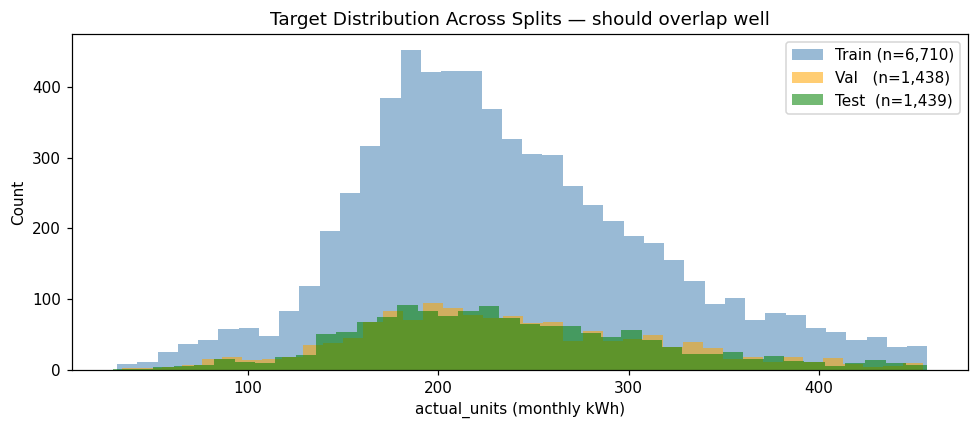

Train target mean: 234.2  std: 77.5
Val   target mean: 235.5  std: 78.8
Test  target mean: 235.5  std: 77.9


In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 3 · Train / Validation / Test Split + Scaling
# ─────────────────────────────────────────────────────────────
# Split strategy:
#   70% Train  — model learns from this
#   15% Val    — hyperparameter tuning uses this (never seen by tuner as test)
#   15% Test   — final holdout, touched only once at the end
#
# Scaling:
#   StandardScaler fitted on X_train ONLY.
#   X_val and X_test are transformed (not re-fit) to prevent
#   any information from val/test leaking into the scaler parameters.

X = df[ALL_FEATURES]
y = df[TARGET]

# 70 / 30 split first
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

# 50 / 50 of the 30% → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print(f'Train : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Val   : {X_val.shape[0]:,} rows ({X_val.shape[0]/len(df)*100:.1f}%)')
print(f'Test  : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(df)*100:.1f}%)')
print()

# ── Scale continuous features ──────────────────────────────────
scaler = StandardScaler()

X_train_sc = X_train.copy()
X_val_sc   = X_val.copy()
X_test_sc  = X_test.copy()

X_train_sc[SCALE_FEATURES] = scaler.fit_transform(X_train[SCALE_FEATURES])
X_val_sc[SCALE_FEATURES]   = scaler.transform(X_val[SCALE_FEATURES])
X_test_sc[SCALE_FEATURES]  = scaler.transform(X_test[SCALE_FEATURES])

# Verify scaler fitted only on train
print(f'Scaler mean (hist_avg_units): {scaler.mean_[0]:.2f}  '
      f'(should be ~train mean = {y_train.mean():.0f} range)')
print(f'Scaled train hist_avg mean  : {X_train_sc["hist_avg_units"].mean():.4f}  (should be ~0)')
print(f'Scaled train hist_avg std   : {X_train_sc["hist_avg_units"].std():.4f}   (should be ~1)')
print()

# Save scaler and split indices for Team 3 (deployment)
joblib.dump(scaler, 'scaler_team2.pkl')
np.save('test_indices.npy', X_test.index.values)
print('scaler_team2.pkl saved.')
print('test_indices.npy saved.')

# ── Verify target distribution is similar across splits ────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_train, bins=40, alpha=0.55, label=f'Train (n={len(y_train):,})', color='steelblue')
ax.hist(y_val,   bins=40, alpha=0.55, label=f'Val   (n={len(y_val):,})',   color='orange')
ax.hist(y_test,  bins=40, alpha=0.55, label=f'Test  (n={len(y_test):,})',  color='green')
ax.set_xlabel('actual_units (monthly kWh)')
ax.set_ylabel('Count')
ax.set_title('Target Distribution Across Splits — should overlap well')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Train target mean: {y_train.mean():.1f}  std: {y_train.std():.1f}')
print(f'Val   target mean: {y_val.mean():.1f}  std: {y_val.std():.1f}')
print(f'Test  target mean: {y_test.mean():.1f}  std: {y_test.std():.1f}')